# QCircuitHEOM-figures

In [ ]:
%load_ext autoreload
%autoreload 2

from qcheom import *
plt.style.use('qcheom-default')

import numpy as np 
import qutip as q
import matplotlib.pyplot as plt
import pandas as pd
import time

red, blue, orange, grey = '#B74244', '#459DD9', '#ED8532', '#A9ACBC'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


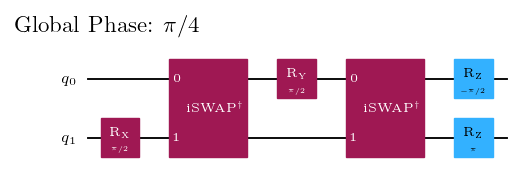

In [4]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import XXPlusYYGate

qc = QuantumCircuit(2, name=r'iSWAP$^\dagger$')
qc.append(XXPlusYYGate(np.pi, 0), [0, 1])
iSwapD = qc.to_gate

qc = QuantumCircuit(2)
qc.rx(0.5*np.pi, 1)
qc.append(iSwapD(), [0, 1])
qc.ry(0.5*np.pi, 0)
qc.append((iSwapD()), [0, 1])
qc.rz(-0.5*np.pi, 0)
qc.rz(np.pi, 1)
qc.global_phase = 0.25*np.pi

fig, ax = plt.subplots()
qc.draw('mpl', ax=ax)
fig.savefig("development/results/paper/cnot_decomposition.pdf", bbox_inches="tight")
fig.savefig("development/results/paper/cnot_decomposition.svg", bbox_inches="tight")

## Section 2: spectral density

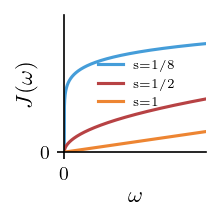

In [33]:
fig, ax = plt.subplots(figsize=(1.7/1.25, 1.7/1.25))

o = np.linspace(0, 0.15, 2000)

ax.plot(o, o**(1/8), label='s=1/8', lw=1.5)
ax.plot(o, o**(1/2), label='s=1/2', lw=1.5)
ax.plot(o, o, label='s=1', lw=1.5)

ax.set_xlim(0, 0.15)
ax.set_ylim(0, 1)
ax.set_xlabel(r'$\omega$', labelpad=1)
ax.set_ylabel(r'$J(\omega)$', labelpad=1)

ax.set_xticks([0])
ax.set_yticks([0])

ax.legend(
    fontsize=6,
    frameon=False
)
fig.savefig("development/results/paper/spectral_density.pdf")
fig.savefig("development/results/paper/spectral_density.svg")

## Section 5: benchmarking

In [ ]:
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

kwargs = {
    "numQ": 2,
    "freqQ": [5, 5],  # GHz
    "rhoIni": [
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ],
    "gateTime": [0.16, 0.16, 0.50],  # ns
    "idlingTime": 0.01,  # ns
    "T": 30,  # mK
    "T1": 32,  # us
    "omegaC": 20,
    "exp": 1/8,
    "tol": 1e-2,
    "dtFB": 0.1,  # ps
    "depth": [1, 1],
    "bondDim": 5,
    "strideTime": 0.001,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/"
kwargs["fileName"] = "delete"
kwargs["qc"] = qc

# expected runtime
calcTimeEvo(**kwargs)

Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 11900


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.22it/s]

Data size: 1190
Time per iteration: 0.31 s
Estimated time: 6.17 min


In [204]:
# A_Bell = np.array([[35.26, 54.12, 82.03],
#                   [54.66, 118.79, 181.91],
#                   [29.75, 73.17, 145.01]]) * 1189 / 100 / 60
A_Bell = np.array([[7.2, 11.13, 16.19],
                   [11.28, 24.44, 38.51],
                   [6.17, 15.09, 29.82]])

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# Manual idle time corresponding to 10 ns.
# This is used here to construct repeated 2pi rotations explicitly.
# Usually, users should set kwargs["idlingTime"]
idling_manual = int(0.10 / (1e-3 * 0.1))

# Qiskit quantum circuit
qc = QuantumCircuit(1)
for _ in range(3):
    qc.rx(np.pi, 0)
    qc.delay(0, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": [
        [1, 0],
        [0, 0],
    ],
    "gateTime": [0.16],  # ns
    "idlingTime": 0,  # ns
    "T": 30,  # mK
    "T1": 10,  # us
    "omegaC": 20,
    "exp": 1/8,
    "tol": 1e-6,
    "dtFB": 0.1,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.001,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/"
kwargs["fileName"] = "delete"
kwargs["qc"] = qc

# expected runtime: 4.5h
calcTimeEvo(**kwargs)

Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 11600


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.26it/s]

Data size: 1160
Time per iteration: 0.44 s
Estimated time: 8.56 min


In [205]:
# A_Id = np.array([[9.44, 14.49, 21.61],
                # [14.60, 30.41, 49.65],
                # [7.66, 20.07, 41.86]]) * 1159 / 100 / 60
A_Id = np.array([[1.93, 3.01, 4.58],
                [3.02, 6.10, 10.15],
                [1.51, 4.06, 8.56]])

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# Manual idle segment corresponding to 10 ns.
idling_manual = int(0.10 / (1e-3 * 0.1))

# Qiskit quantum circuit
qc = QuantumCircuit(1)
for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": [
        [0.5, 0.5],
        [0.5, 0.5],
    ],
    "gateTime": [0.16],  # ns
    "idlingTime": 0,  # ns
    "T": 30,  # mK
    "T1": 32,  # us
    "omegaC": 50,
    "exp": 1/8,
    "tol": 1e-6,
    "dtFB": 0.1,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.001,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/"
kwargs["fileName"] = "delete"
kwargs["qc"] = qc

# expected runtime: 3.5h
calcTimeEvo(**kwargs)

Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 10400


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.31it/s]

Data size: 1040
Time per iteration: 0.43 s
Estimated time: 7.51 min


In [206]:
# A_DD = np.array([[9.48, 16.40, 21.53],
#                 [11.18, 36.52, 52.79],
#                 [7.65, 19.84, 41.26]]) * 1039 / 100 / 60
A_DD = np.array([[1.81, 3.04, 4.03],
                [2.13, 6.64, 9.46],
                [1.36, 3.75, 7.51]])

In [ ]:
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# qiskit quantum circuit
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

kwargs = {
    "numQ": 3,
    "freqQ": [5,5,5],  # GHz
    "rhoIni": [
        [1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
    ],
    "gateTime": [0.16, 0.16, 0.16, 0.50, 0.50],  # ns
    "idlingTime": 0.01,  # ns
    "T": 30,  # mK
    "T1": 32,  # us
    "omegaC": 20,
    "exp": 1/8,
    "tol": 1e-2,
    "dtFB": 0.1,  # ps
    "depth": [1, 1, 1],
    "bondDim": 5,
    "strideTime": 0.001,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/"
kwargs["fileName"] = "delete"
kwargs["qc"] = qc

# expected runtime: 64h
calcTimeEvo(**kwargs)

Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 23100


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.49it/s]

Data size: 2310
Time per iteration: 0.67 s
Estimated time: 25.89 min


In [210]:
# A_GHZ = np.array([[77.32, 119.04, 175.80],
#                  [117.50, 252.46, 747.89],
#                  [64.72, 160.10, 314.25]]) * 2309 / 100 / 60
A_GHZ = np.array([[31.56, 47.37, 69.63],
                 [47.29, 100.82, 159.49],
                 [26.62, 63.01, 123.60]])

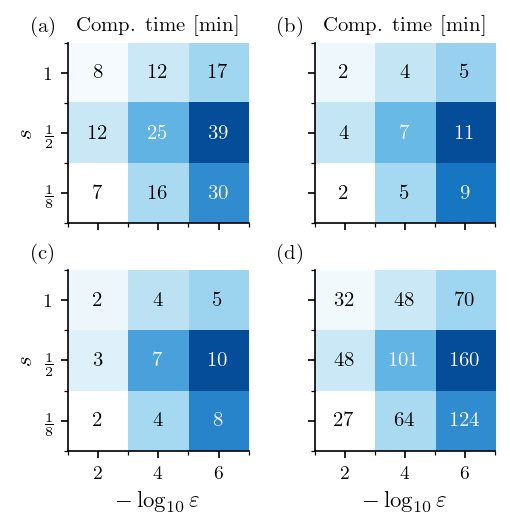

In [211]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

# --- Colormap ---
blue_colors = ["#FFFFFF", "#C6E6F5", "#9CD4F0", "#72C1EA", "#459DD9", "#1272C0", "#064D99"]
blue_cmap = LinearSegmentedColormap.from_list("custom_blue", blue_colors)
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

A_list = [A_Bell, A_Id, A_DD, A_GHZ]

# --- Plot ---
fig, axes = plt.subplots(2,2, figsize=(3.4, 3.4), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):

    A_heat = A_list[i]
    # A_heat = np.array([[float(f"{x:.2g}") for x in row] for row in A])

    # --- labels ---
    labels_tol = ['2', '4', '6']
    labels_s = [r'$1$', r'$\frac{1}{2}$', r'$\frac{1}{8}$']
    
    norm = Normalize(vmin=A_heat.min(), vmax=A_heat.max())
    im = ax.imshow(A_heat, cmap=blue_cmap, norm=norm)

    ax.text(
        -0.2, 1.15,
        panel_labels[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )
    
    ax.set_xticks(np.arange(A_heat.shape[1]), labels_tol)
    ax.set_yticks(np.arange(A_heat.shape[0]), labels_s)
    
    # optional cell borders
    ax.set_xticks(np.arange(-.5, A_heat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, A_heat.shape[0], 1), minor=True)
    
    # cell labels
    for row in range(A_heat.shape[0]):
        for col in range(A_heat.shape[1]):
            val = A_heat[row, col]
            text_color = "white" if norm(val) > 0.5 else "black"
            ax.text(col, row, int(np.ceil(val)),
                    ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color=text_color)
    
axes[0,0].set_title('Comp. time [min]', fontsize=10)
axes[0,1].set_title('Comp. time [min]', fontsize=10)
axes[1,0].set_xlabel(r'$-\log_{10}\varepsilon$')
axes[1,1].set_xlabel(r'$-\log_{10}\varepsilon$')
axes[0,0].set_ylabel(r'$s$')
axes[1,0].set_ylabel(r'$s$')

fig.savefig("development/results/paper/benchmark/comp_time.pdf")
fig.savefig("development/results/paper/benchmark/comp_time.svg")

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# Manual idle time corresponding to 10 ns.
# This is used here to construct repeated 2pi rotations explicitly.
# Usually, users should set kwargs["idlingTime"]
idling_manual = int(0.10 / (1e-3 * 0.05))

# Qiskit quantum circuit
qc = QuantumCircuit(1)
for _ in range(3):
    qc.rx(np.pi, 0)
    qc.delay(0, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)

# for exp in [1, 1/2, 1/8]:
exp = 1
for i, bondDim in enumerate([20,10,5]):
    for j, depth in enumerate([1,2,3]):
        kwargs = {
            "numQ": 1,
            "freqQ": [5],  # GHz
            "rhoIni": [
                [1, 0],
                [0, 0],
            ],
            "gateTime": [0.16],  # ns
            "idlingTime": 0,  # ns
            "T": 30,  # mK
            "T1": 10,  # us
            "omegaC": 20,
            "exp": exp,
            "tol": 1e-6,
            "dtFB": 0.05,  # ps
            "depth": [depth],
            "bondDim": bondDim,
            "strideTime": 0.001,  # ns
            "useRFPlus": False,
            "isRK13": False,
        }
        
        kwargs["directory"] = "development/results/local/"
        kwargs["fileName"] = "delete"
        kwargs["qc"] = qc
        
        # expected runtime
        calcTimeEvo(**kwargs)

Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 23200


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.22s/it]


Data size: 1160
Time per iteration: 1.22 s
Estimated time: 23.56 min
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 23200


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:09<00:00,  1.83s/it]


Data size: 1160
Time per iteration: 1.83 s
Estimated time: 35.33 min
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 23200


...

Data size: 1160
Time per iteration: 0.46 s
Estimated time: 8.81 min
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 23200


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.08it/s]


Data size: 1160
Time per iteration: 0.48 s
Estimated time: 9.29 min
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/qcData_delete.qpy.
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/local/delete.csv.
Total step: 23200


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.02it/s]

Data size: 1160
Time per iteration: 0.49 s
Estimated time: 9.55 min


In [226]:
A_s1 = np.array([[23.56, 35.33, 46.42],
                [11.53, 13.33, 15.13],
                [8.81, 9.29, 9.55]])

In [227]:
A_s2 = np.array([[61.61, 85.79, 110.80],
                [27.63, 32.09, 35.79],
                [20.49, 21.74, 22.93]])

In [228]:
A_s3 = np.array([[50.92, 71.05, 94.75],
                [22.88, 26.31, 29.77],
                [16.47, 17.76, 18.24]])

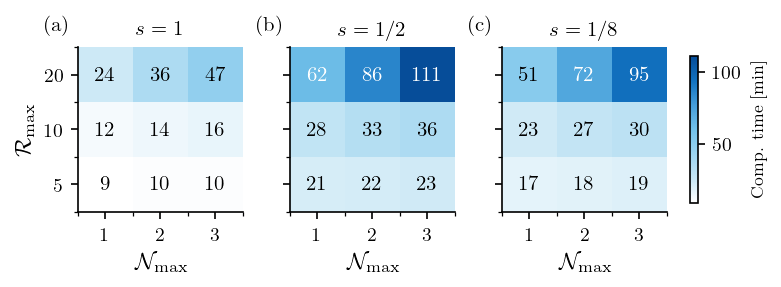

In [249]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

# --- Colormap ---
blue_colors = ["#FFFFFF", "#C6E6F5", "#9CD4F0", "#72C1EA", "#459DD9", "#1272C0", "#064D99"]
blue_cmap = LinearSegmentedColormap.from_list("custom_blue", blue_colors)

A_list = [A_s1, A_s2, A_s3]
panel_labels = ["(a)", "(b)", "(c)"]

# shared normalization across all panels
vmin = min(np.ceil(A).astype(int).min() for A in A_list)
vmax = max(np.ceil(A).astype(int).max() for A in A_list)
norm = Normalize(vmin=vmin, vmax=vmax)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(3.4*1.5, 1.2*3.4/2), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):

    A = A_list[i]
    A_heat = np.ceil(A).astype(int)

    # --- labels ---
    labels_N = ['1', '2', '3']
    labels_R = ['20', '10', '5']
    
    im = ax.imshow(A_heat, cmap=blue_cmap, norm=norm)

    ax.text(
        -0.2, 1.2,
        panel_labels[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )
    
    ax.set_xticks(np.arange(A_heat.shape[1]), labels_N)
    ax.set_yticks(np.arange(A_heat.shape[0]), labels_R)
    
    # optional cell borders
    ax.set_xticks(np.arange(-.5, A_heat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, A_heat.shape[0], 1), minor=True)
    
    # cell labels
    for row in range(A_heat.shape[0]):
        for col in range(A_heat.shape[1]):
            val = A_heat[row, col]
            text_color = "white" if norm(val) > 0.5 else "black"
            ax.text(
                col, row, f"{val}",
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                color=text_color
            )

axes[0].set_title(r'$s=1$', fontsize=10)
axes[1].set_title(r'$s=1/2$', fontsize=10)
axes[2].set_title(r'$s=1/8$', fontsize=10)

axes[0].set_xlabel(r'$\mathcal{N}_{\max}$')
axes[1].set_xlabel(r'$\mathcal{N}_{\max}$')
axes[2].set_xlabel(r'$\mathcal{N}_{\max}$')
axes[0].set_ylabel(r'$\mathcal{R}_{\max}$')

# shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.5, pad=0.04)
cbar.set_label("Comp. time [min]", fontsize=8)

# fig.suptitle("Comp. time [min]", fontsize=10, y=-0.05)

fig.savefig("development/results/paper/benchmark/comp_time2.pdf", bbox_inches="tight")
fig.savefig("development/results/paper/benchmark/comp_time2.svg", bbox_inches="tight")

## Section 6: tomography and error mitigation

{'directory': 'development/results/hpc/error_mitigation', 'fileName': '21838055', 'numQ': 1, 'freqQ': [5.0], 'gateTime': [16.0], 'T': array([30.]), 'T1': array([1.]), 'omegaC': [20], 'exp': [1], 'tol': [1e-06], 'idlingTime': 0.0, 'dtFB': 0.1, 'depth': [1], 'bondDim': 5, 'strideTime': 0.10000000000000002, 'useRFPlus': False, 'isRK13': False, 'rhoIni': array([[0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), 'qc': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000024F07744510>}
------------
{'idlingTime': 0.0, 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 7.998738455610369, 'kappa': 5.066059182116889e-06, 'omegaC': 20, 'exp': 1, 'tol': 1e-06}], 'dtFB': 0.0031415926535897937, 'stride': 1000, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.0, 0.0], [0.0, 1.0]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], '

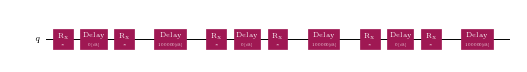

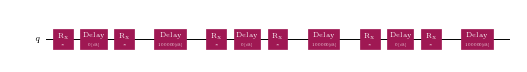

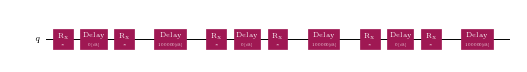

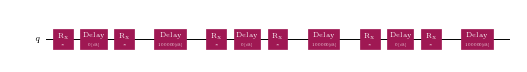

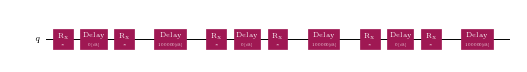

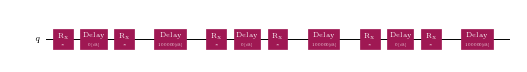

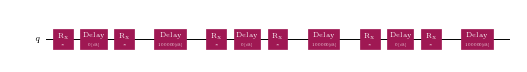

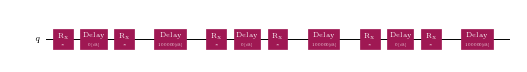

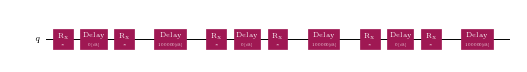

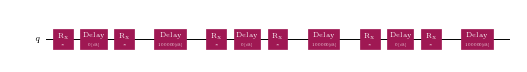

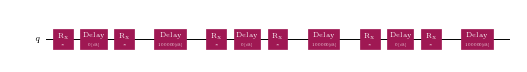

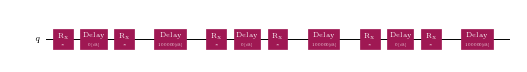

In [124]:
directory = "development/results/hpc/error_mitigation"
fileNames = ['21838055', '21838056', '21838059', # s1_zm, s1_xp, s1_yp
             '21838062', '21838063', '21838067', # s2_zm, s2_xp, s2_yp
             '21838068', '21838072', '21838074', # s8_zm, s8_xp, s8_yp
             '21838100', '21838103', '21838114', # s1_zp, s2_zp, s8_zp
            ]

for i, fileName in enumerate(fileNames):
    
    # load kwargs from QPY file 
    kwargs = getKwargs(directory, fileName)
    print(kwargs)
    print('------------')
    print(kwargs['qc'].metadata)
    print('------------')

    fig, ax = plt.subplots()
    kwargs['qc'].draw('mpl', ax=ax)
    
    # load result from CSV file
    # t_list, rdo_list = getResult(directory, fileName)

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# Manual idle time corresponding to 10 ns.
# This is used here to construct repeated 2pi rotations explicitly.
# Usually, users should set kwargs["idlingTime"]
idling_manual = int(10 / (1e-3 * 0.1))

# Qiskit quantum circuit
qc = QuantumCircuit(1)
for _ in range(3):
    qc.rx(np.pi, 0)
    qc.delay(0, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    # "rhoIni": [
    #     [1, 0],
    #     [0, 0],
    # ],
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": 30,  # mK
    "T1": 1,  # us
    "omegaC": 20,
    # "exp": 1,
    "tol": 1e-6,
    "dtFB": 0.1,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["qc"] = qc

# Initial states used for error mitigation
I = np.eye(2, dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

zp = (I + sz) / 2
zm = (I - sz) / 2
xp = (I + sx) / 2
yp = (I + sy) / 2

for exp, label in [[1,'1'], [1/2, '2'], [1/8, '8']]:
    kwargs["directory"] = "development/results/hpc/error_mitigation/"
    for file_name, rho_ini in zip(["zm", "zp", "xp", "yp"], [zp, zm, xp, yp]):
        kwargs["fileName"] = "s" + label + '_' + file_name
        kwargs["rhoIni"] = rho_ini
        kwargs["exp"] = exp

        calcTimeEvoHPC(submissionParams, **kwargs)

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\mitigation\decomposition.py:87: ComplexWarning: Casting complex values to real discards the imaginary part
  PTM_list[i + 1, 0, :] = 0.5 * (zp + zm)  # identity
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\mitigation\decomposition.py:88: ComplexWarning: Casting complex values to real discards the imaginary part
  PTM_list[i + 1, 1, :] = 0.5 * (2 * xp - zp - zm)  # sigma_x
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\mitigation\decomposition.py:89: ComplexWarning: Casting complex values to real discards the imaginary part
  PTM_list[i + 1, 2, :] = 0.5 * (2 * yp - zp - zm)  # sigma_y
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\mitigation\decomposition.py:90: ComplexWarning: Casting complex values to real discards the imaginary part
  PTM_list[i + 1, 3, :] = 0.5 * (zp - zm)  # sigma_z
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_project

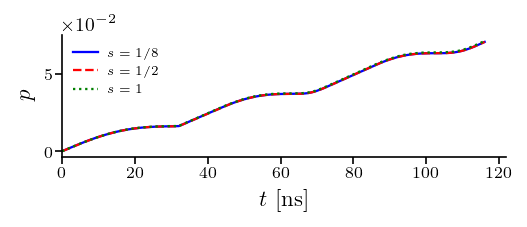

In [ ]:
from qcheom.mitigation import *

fig, ax = plt.subplots(figsize=(3.4,2.1/1.5))
colors = ['b', 'r', 'g']
labels = [r'$s=1/8$', r'$s=1/2$', r'$s=1$']
ls = ['-','--', ':']

for j, x in enumerate(['s1', 's2', 's8']):

    directory = f'development/results/paper/error_mitigation'
    input_array = []
    for fileName in ['zp','zm','xp','yp']:
        fileName = x + '_' + fileName
        qcFilePath = os.path.join(os.getcwd(), directory, 'qcData_' + fileName + '.qpy')
        csvFilePath = os.path.join(os.getcwd(), directory, fileName + '.csv')
        
        # load qc with metadata
        qc = loadQC(qcFilePath)
        metadata = qc.metadata
        
        # load result
        t_list, dm_list = loadResult(csvFilePath)
        t_list /= metadata['omegaQmax']
        input_array.append( [[q.expect(q.Qobj(rho), op) for rho in dm_list] for op in [q.sigmax(),q.sigmay(),q.sigmaz()]] )
    input_array = np.array(input_array)
    
    PTM_list = construct_PTM(input_array)
    
    p_list = []
    for i in range(PTM_list.shape[-1]):
        PTM = PTM_list[:,:,i]    
        inv_PTM = invert_PTM(PTM)
        inv_choi = PTM_to_Choi(q.Qobj(inv_PTM))
        p, choi_plus, choi_minus = get_CPTP_Choi(inv_choi)
        p_list.append(p)
    
    ax.plot(t_list[1:], p_list, color=colors[j], label=labels[j], ls=ls[j],lw=1.1)
ax.set_xlabel(r'$t$ [ns]')
ax.set_ylabel(r'$p$')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.legend(fontsize=6, frameon=False, ncols=1, loc='upper left')

ax.set_xlim(0)
ax.tick_params(axis="both", labelsize=8, pad=1)

fig.savefig('development/results/paper/error_mitigation/error_mitigation.pdf')
fig.savefig('development/results/paper/error_mitigation/error_mitigation.svg')

## Appendix A: pole count

In [9]:
exp = 1/2
omegaC = 50

T1 = 32 # us
kappa = 1 / (10*np.pi * 1e9 * np.array(T1) * 1e-6 * 2 * np.pi) # hbar kappa
kappa = 1e-6 / 2 / np.pi

T_values = np.array([5, 10, 20, 35, 50, 75, 100, 150, 200, 250][::-1])
beta_values = c.hbar * 10*np.pi * 1e9 / (np.array(T_values) * 1e-3 * c.k)
# beta_values = np.linspace(50, 1, 11)
tol_values = np.array([4,5,6,7,8,9,10])

K_map = np.zeros((len(tol_values), len(beta_values)), dtype=int)

# for i, tol in tqdm(enumerate(tol_values)):
#     tol = 10.0**(-tol)
#     for j, beta in enumerate(beta_values):
#         bathParams = {
#             'type': 'broadband',
#             'beta': beta,
#             'kappa': kappa,
#             'omegaC': omegaC,
#             'exp': exp,
#             'tol': tol,
#         }
#         z, d = getBathParams(bathParams)
#         K_map[i, j] = len(z)

# np.save('K_s2.npy', K_map)

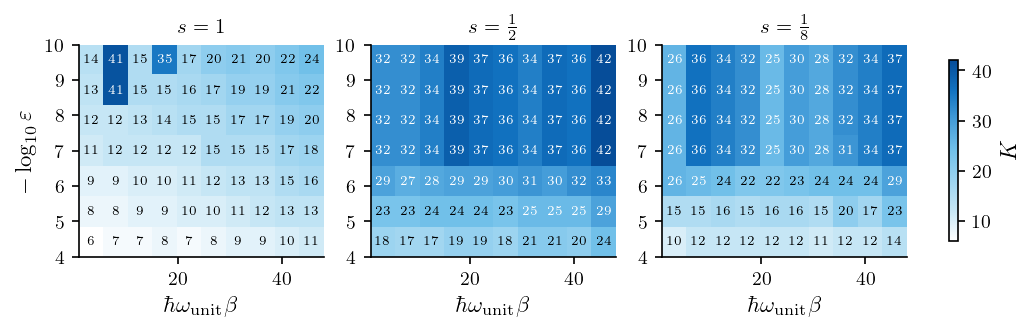

In [10]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

# --- Data ---
A_s1 = np.load('development/results/paper/pole_count/K_s1.npy')
A_s2 = np.load('development/results/paper/pole_count/K_s2.npy')
A_s8 = np.load('development/results/paper/pole_count/K_s8.npy')

A_raw_list = [A_s1, A_s2, A_s8]
A_list = [np.ceil(A).astype(int) for A in A_raw_list]

titles = [r'$s=1$', r'$s=\frac{1}{2}$', r'$s=\frac{1}{8}$']

# --- Colormap ---
blue_colors = ["#FFFFFF", "#C6E6F5", "#9CD4F0", "#72C1EA",
               "#459DD9", "#1272C0", "#064D99"]
blue_cmap = LinearSegmentedColormap.from_list("custom_blue", blue_colors)

# --- Shared normalization ---
vmin = min(A.min() for A in A_list)
vmax = max(A.max() for A in A_list)
norm = Normalize(vmin=vmin, vmax=vmax)

# --- Figure ---
fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.1))

for idx, ax in enumerate(axes):
    A = A_list[idx]

    im = ax.imshow(A, cmap=blue_cmap, aspect="auto", norm=norm, origin='lower', extent=[beta_values[0],beta_values[-1],tol_values[0],tol_values[-1]])

    ax.set_title(titles[idx], fontsize=10)

    ax.set_xlabel(r"$\hbar\omega_{\mathrm{unit}} \beta$")
    ax.set_yticks(tol_values)
    # ax.set_xticks(beta_values)
    if idx == 0:
        ax.set_ylabel(r"$-\log_{10}\varepsilon$")

    xmin, xmax = beta_values[0], beta_values[-1]
    ymin, ymax = tol_values[0], tol_values[-1]
    nrows, ncols = A.shape
    x_edges = np.linspace(xmin, xmax, ncols + 1)
    y_edges = np.linspace(ymin, ymax, nrows + 1)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    for row in range(A.shape[0]):
        for col in range(A.shape[1]):
            val = A[row, col]
            text_color = "white" if norm(val) > 0.5 else "black"
            ax.text(
                x_centers[col],
                y_centers[row],
                f"{val}",
                ha="center",
                va="center",
                fontsize=6,
                fontweight="bold",
                color=text_color,
            )

cbar = fig.colorbar(im, ax=axes, location="right", shrink=0.85)
cbar.set_label(r"$K$")

# fig.savefig("development/results/paper/pole_count/pole_count.pdf")
# fig.savefig("development/results/paper/pole_count/pole_count.svg")

## Appendix: code

In [ ]:
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

kwargs = {
    "numQ": 2,
    "freqQ": [5, 5],  # GHz
    "rhoIni": [
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ],
    "gateTime": [16, 16, 50],  # ns
    "idlingTime": 1,  # ns
    "T": 30,  # mK
    "T1": 32,  # us
    "omegaC": 20,
    "exp": 1 / 8,
    "tol": 1e-6,
    "dtFB": 1.0,  # ps
    "depth": [1, 1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = None
kwargs["fileName"] = "delete"
kwargs["qc"] = qc

# expected runtime: 
# calcTimeEvo(**kwargs)

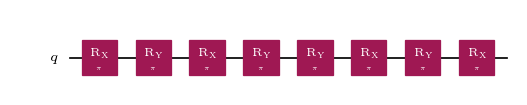

In [62]:
from ttheom import plotPulseSeq

# kwargs = ...
directory = "development/results/paper/appendix"
fileName = "sim_Bell"

# plot qc
fig, ax = plotQC(**kwargs)
fig.savefig(os.path.join(directory, f'qc_{fileName}.pdf'))

# plot pulse sequence
fig, ax = plotPulseSeq(**kwargs)
fig.savefig(os.path.join(directory, f'pulseSeq_{fileName}.pdf'))